# Pure-state half-system entanglement-energy density and variance
Use 100 independent pure-state endpoints for each $N_y=24,28,32,40,50,60$, with $N_x=20$, hard walls, $\alpha_1=1$, $\alpha_2=30$, $n_{\mathrm{shell}}=1$, and $T=2N_y$. The subsystem is all x, both orbitals, and $y=0,\ldots,N_y/2-1$; a common fixed origin $y_0=0$ is used for all sizes. This analysis is distinct from mixed-state purification.

Convert each retained half-system centered occupation via
$$\varepsilon=\log[(1-\lambda)/(1+\lambda)],\qquad|\lambda|\le L=0.99.$$
Pool retained modes from the 100 trajectories. The conditional density is normalized to unit area inside $[-E,E]$, with $E=\log199$. Each retained mode has equal weight; trajectories with more retained modes contribute more weight. Compute the variance directly from energies,
$$V_\varepsilon=\langle\varepsilon^2\rangle_{\rm pool}-\langle\varepsilon\rangle_{\rm pool}^2,$$
using the population convention, not a histogram approximation. This is the variance of energies under the spectral density, not variability of bin heights. Error bars are one standard error from deleting whole trajectories in a jackknife, retaining correlations among levels. A uniform density over this finite window has variance $E^2/3$. No finite-size scaling fit is imposed.

In [1]:
import os
CPU_RANGE=(8,15) # Editable inclusive CPU range.
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):
    os.environ[key]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Inputs and configuration
Validate the existing spectra against their saved SHA-256 identities. Existing production provenance documents the sample coverage and acquisition checks.

In [2]:
from pathlib import Path
import os,json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd()
SMALL=OUT.parent/'half_system_centered_spectrum_n20_sizes_hard_alpha1_v1'
LARGE=OUT.parent/'stochastic_equilibrium_spectral_comparison_v1'
NY_VALUES=[24,28,32,40,50,60]
L=.99
E=float(np.log1p(L)-np.log1p(-L))
def sha(p):
    with p.open('rb') as f:return hashlib.file_digest(f,'sha256').hexdigest()
overlay=json.loads((SMALL/'overlay_diagnostics.json').read_text())
manifest=json.loads((LARGE/'completion_manifest.json').read_text())
spectra={};inputs=[]
for ny in NY_VALUES[:3]:
    f=SMALL/f'centered_spectra_Ny{ny:03}.npz'
    digest=sha(f)
    assert digest==overlay['sizes'][str(ny)]['spectra_sha256']
    with np.load(f) as z:
        assert np.array_equal(z['sample_ids'],np.arange(100))
        assert np.array_equal(z['subsystem_indices'],np.arange(20*ny))
        spectra[ny]=z['eigenvalues']
    inputs.append({'path':str(f),'bytes':f.stat().st_size,'sha256':digest})
f=LARGE/'extended_size_controls.npz'
digest=sha(f);assert digest==manifest['files'][f.name]['sha256']
inputs.append({'path':str(f),'bytes':f.stat().st_size,'sha256':digest})
with np.load(f) as z:
    for ny in NY_VALUES[3:]:spectra[ny]=z[f'stochastic_{ny}']
metadata={'Nx':20,'Ny_values':NY_VALUES,'samples_per_size':100,'construction':'hard',
 'alpha_1':1,'alpha_2':30,'nshell':1,'state':'pure','endpoint':'T=2Ny',
 'subsystem':'all x, both orbitals, y=0..Ny/2-1','origin_y':0,'L':L,
 'energy_limit':E,'normalization':'unit area, pooled retained modes',
 'variance':'population second central moment of retained energies',
 'uncertainty':'one trajectory-delete jackknife standard error'}
(OUT/'input_provenance.json').write_text(json.dumps({'configuration':metadata,'inputs':inputs,
 'small_size_provenance':overlay,
 'large_size_provenance':json.loads((LARGE/'extended_input_provenance.json').read_text())},indent=2)+'\n')
display(pd.Series(metadata))

Nx                                                                 20
Ny_values                                    [24, 28, 32, 40, 50, 60]
samples_per_size                                                  100
construction                                                     hard
alpha_1                                                             1
alpha_2                                                            30
nshell                                                              1
state                                                            pure
endpoint                                                        T=2Ny
subsystem                           all x, both orbitals, y=0..Ny/2-1
origin_y                                                            0
L                                                                0.99
energy_limit                                                 5.293305
normalization                        unit area, pooled retained modes
variance            

## Retained energies and variance
Retain sample labels so uncertainty calculations resample independent trajectories rather than individual eigenvalues.

In [3]:
energies={};summary=[];cache={};sample_rows=[]
for ny in tqdm(NY_VALUES,desc='Transform pure-state spectra',unit='size'):
    lam=spectra[ny]
    assert lam.shape==(100,20*ny)
    assert np.isfinite(lam).all() and np.max(np.abs(lam))<=1+1e-8
    mask=np.abs(lam)<=L
    sid,mode=np.nonzero(mask)
    v=lam[mask]
    eps=np.log1p(-v)-np.log1p(v)
    assert np.isfinite(eps).all() and np.max(np.abs(eps))<=E
    assert np.allclose(-np.tanh(eps/2),v,rtol=0,atol=5e-16)
    counts=np.bincount(sid,minlength=100)
    sums=np.bincount(sid,weights=eps,minlength=100)
    sums2=np.bincount(sid,weights=eps**2,minlength=100)
    assert np.all(counts>0)
    total=counts.sum();mean=eps.mean();variance=eps.var(ddof=0)
    assert np.isclose(variance,sums2.sum()/total-mean**2,rtol=0,atol=1e-12)
    leave_count=total-counts
    leave_mean=(sums.sum()-sums)/leave_count
    leave_variance=(sums2.sum()-sums2)/leave_count-leave_mean**2
    jackknife_se=np.sqrt(99/100*np.sum((leave_variance-leave_variance.mean())**2))
    energies[ny]=eps
    cache[f'energy_Ny{ny:03}']=eps;cache[f'sample_id_Ny{ny:03}']=sid
    cache[f'mode_index_Ny{ny:03}']=mode;cache[f'counts_by_sample_Ny{ny:03}']=counts
    row={'Ny':ny,'Nx':20,'Ay':ny//2,'cycle':2*ny,'samples':100,'origin_y':0,
         'L':L,'retained_modes':int(total),'mean_retained_per_sample':float(counts.mean()),
         'retained_fraction':float(total/lam.size),'energy_mean':float(mean),
         'energy_variance':float(variance),'variance_jackknife_se':float(jackknife_se),
         'uniform_window_variance':float(E**2/3)}
    summary.append(row)
    for s in range(100):
        sample_rows.append({'Ny':ny,'sample_id':s,'retained_modes':int(counts[s]),
                           'energy_sum':float(sums[s]),'energy_square_sum':float(sums2[s])})
summary=pd.DataFrame(summary)
summary.to_csv(OUT/'variance_vs_size.csv',index=False)
pd.DataFrame(sample_rows).to_csv(OUT/'sample_moments.csv',index=False)
np.savez_compressed(OUT/'retained_energies.npz',**cache,L=L,Ny_values=NY_VALUES)
display(summary[['Ny','retained_modes','energy_mean','energy_variance','variance_jackknife_se']])

Transform pure-state spectra:   0%|          | 0/6 [00:00<?, ?size/s]

,Ny,retained_modes,energy_mean,energy_variance,variance_jackknife_se
0,24,3098,0.023265,9.337745,0.032569
1,28,3129,-0.022235,9.369625,0.031437
2,32,3120,-0.016560,9.333198,0.030580
3,40,3155,-0.012233,9.306221,0.028425
4,50,3180,0.002431,9.335416,0.031168
5,60,3196,0.006589,9.352419,0.032286


## Spectral density and its variance versus system size
Use identical bins for all sizes, with a central bin straddling zero. The dashed reference gives the variance of a uniform distribution in the same window.

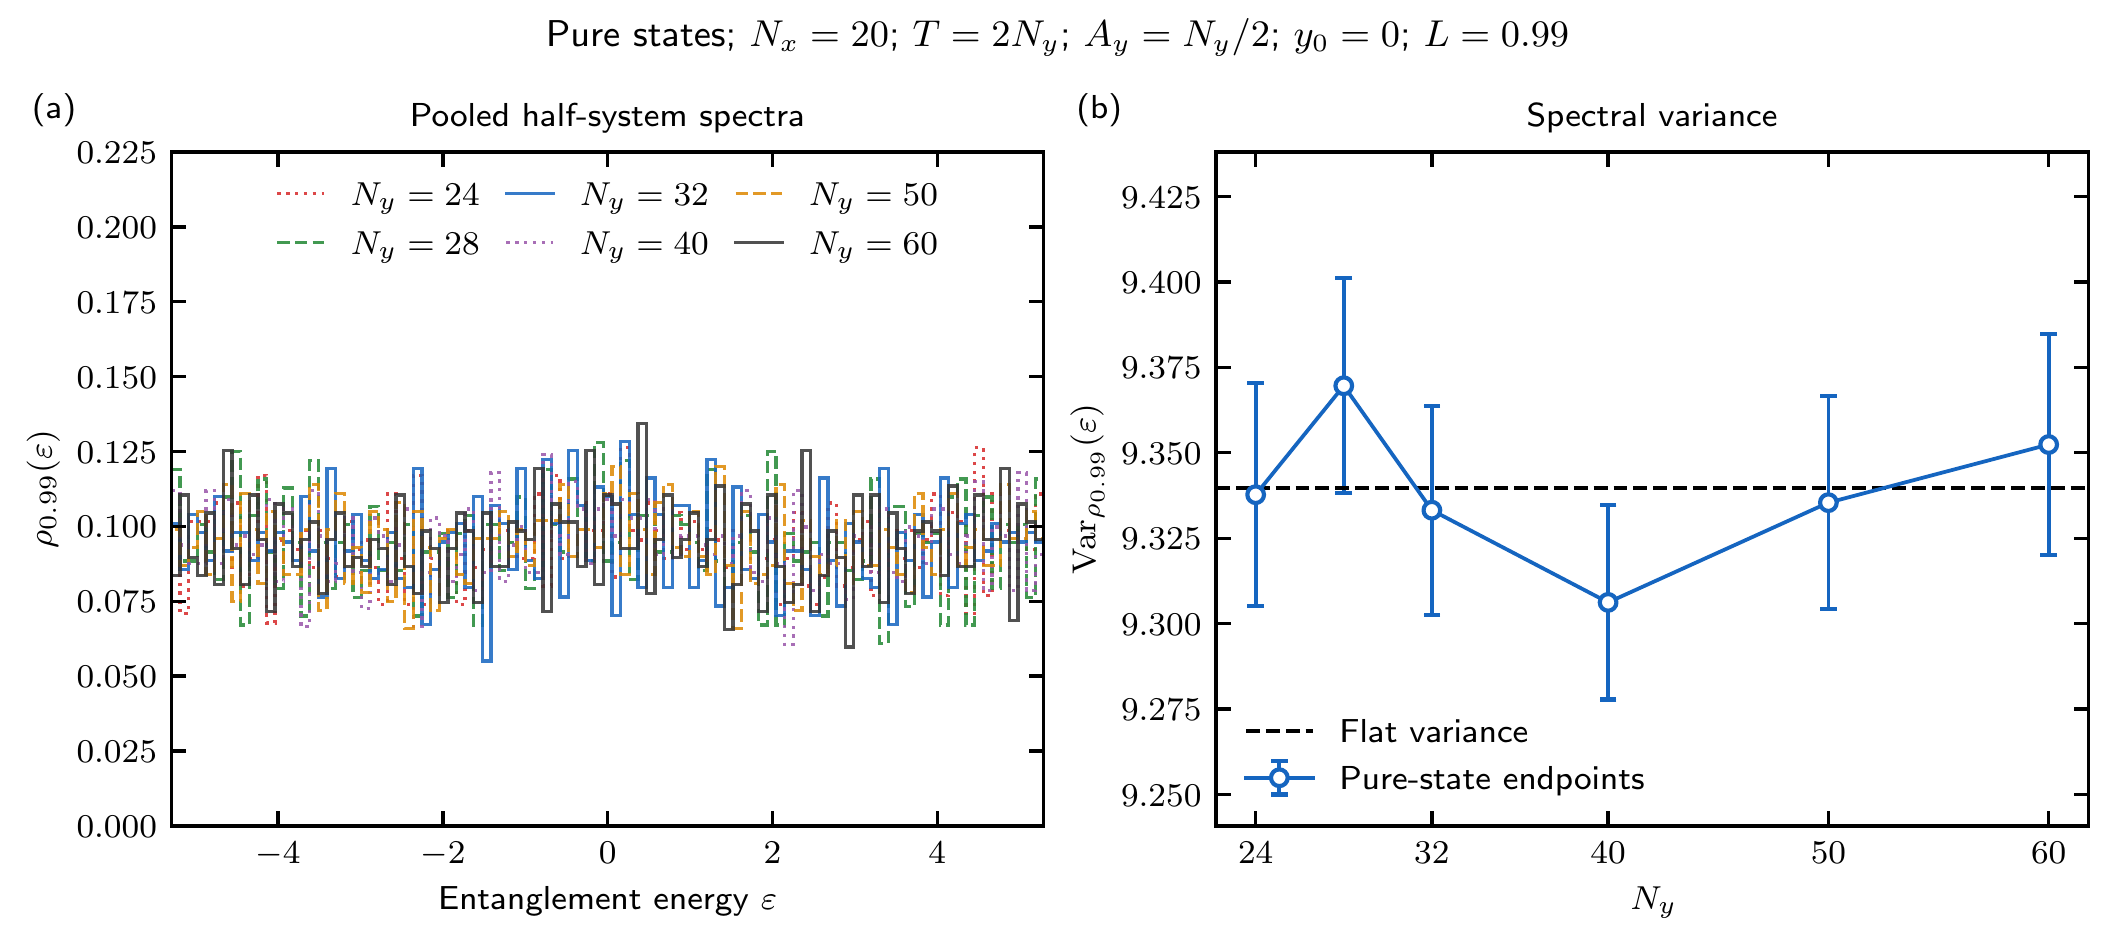

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
BINS=101
edges=np.linspace(-E,E,BINS+1)
histograms={};hist_rows=[]
for ny in NY_VALUES:
    counts,_=np.histogram(energies[ny],edges)
    density=counts/(counts.sum()*np.diff(edges))
    assert counts.sum()==len(energies[ny])
    assert np.isclose(np.dot(density,np.diff(edges)),1,rtol=0,atol=1e-14)
    histograms[ny]=density
    for j in range(BINS):
        hist_rows.append({'Ny':ny,'left':edges[j],'right':edges[j+1],
                          'count':int(counts[j]),'density':float(density[j])})
pd.DataFrame(hist_rows).to_csv(OUT/'spectral_densities.csv',index=False)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in',
 'legend.fontsize':8,'legend.frameon':False})
fig,axes=plt.subplots(1,2,figsize=(7.05,3.15))
colors=['#d62728','#228833','#1565c0','#9955aa','#dd8800','#333333']
styles=[':', '--','-',':','--','-']
for ny,color,style in zip(NY_VALUES,colors,styles):
    axes[0].stairs(histograms[ny],edges,color=color,linestyle=style,linewidth=.8,
                   label=rf'$N_y={ny}$',alpha=.85)
axes[0].set(xlabel=r'Entanglement energy $\varepsilon$',ylabel=r'$\rho_{0.99}(\varepsilon)$',
            xlim=(-E,E),ylim=(0,.225),title='Pooled half-system spectra')
axes[0].legend(ncol=3,loc='upper center',columnspacing=.8,handlelength=1.4)
axes[1].errorbar(summary.Ny,summary.energy_variance,yerr=summary.variance_jackknife_se,
                 color='#1565c0',marker='o',mfc='white',ms=4,lw=.9,capsize=2,label='Pure-state endpoints')
axes[1].axhline(E**2/3,color='black',ls='--',lw=.9,label='Flat variance')
axes[1].set(xlabel=r'$N_y$',ylabel=r'$\mathrm{Var}_{\rho_{0.99}}(\varepsilon)$',
            title='Spectral variance',xticks=[24,32,40,50,60])
axes[1].legend(loc='lower left')
axes[1].margins(y=.3)
for ax,letter in zip(axes,['(a)','(b)']):
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.05,letter,transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'Pure states; $N_x=20$; $T=2N_y$; $A_y=N_y/2$; $y_0=0$; $L=0.99$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'pure_energy_density_and_variance.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'pure_energy_density_and_variance.pdf'),str(OUT/'pure_energy_density_and_variance')],check=True)
display(Image(filename=str(OUT/'pure_energy_density_and_variance.png'),width=1000))

## Bar histograms, one system size per panel
The bars show normalized counts in 101 equal-width energy bins. Each panel pools 100 trajectories; the area of each histogram is one.

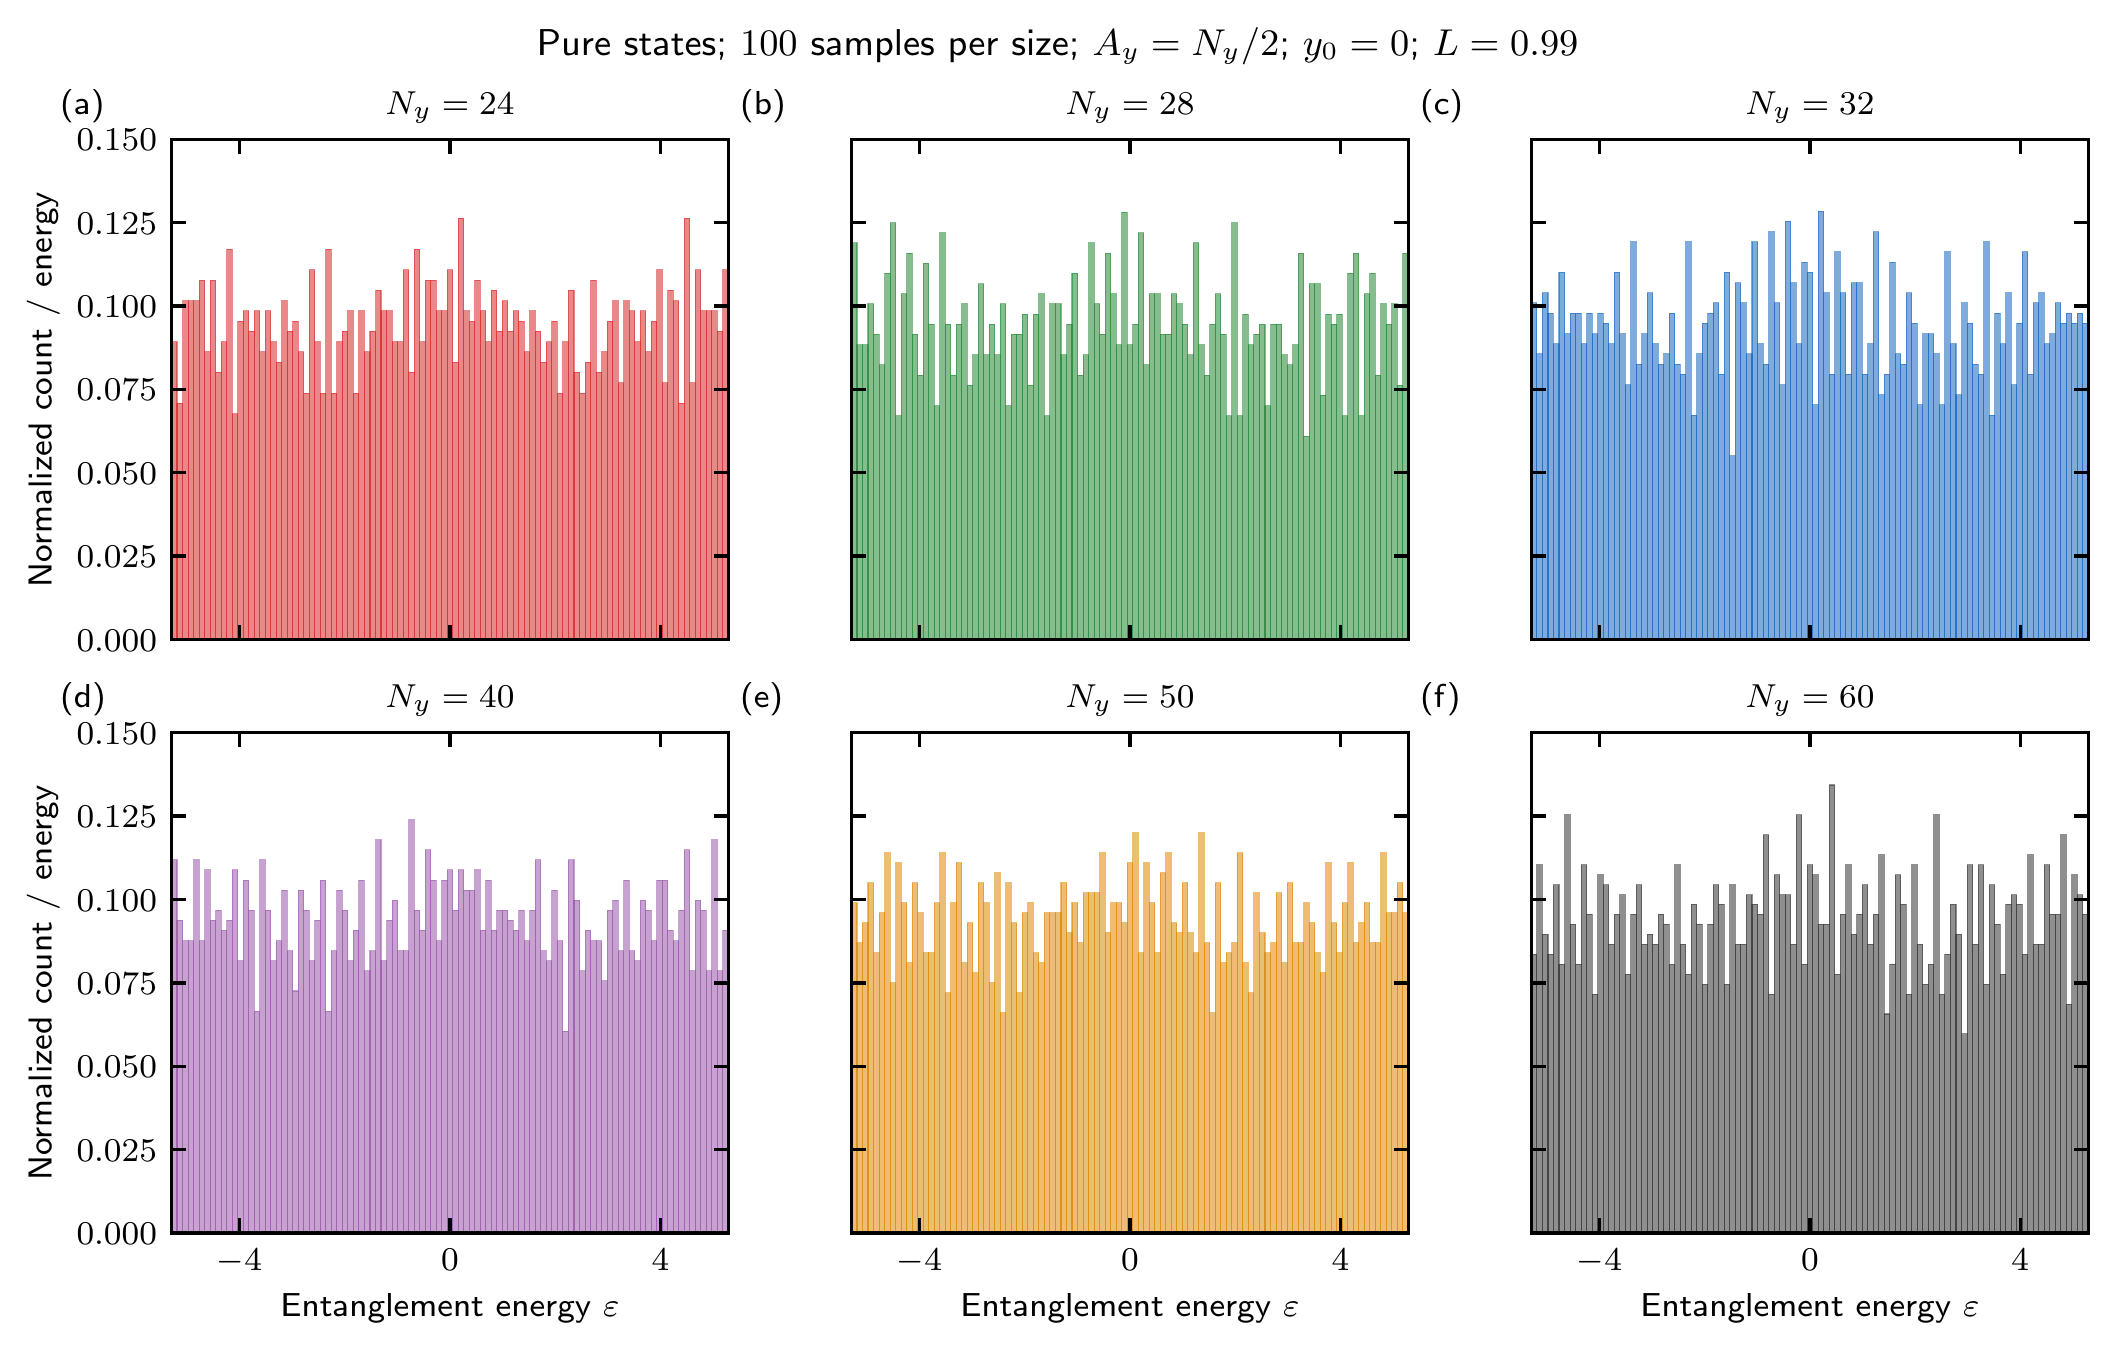

In [5]:
fig,axes=plt.subplots(2,3,figsize=(7.05,4.5),sharex=True,sharey=True)
for ax,ny,color,letter in zip(axes.flat,NY_VALUES,colors,['(a)','(b)','(c)','(d)','(e)','(f)']):
    ax.bar(edges[:-1],histograms[ny],width=np.diff(edges),align='edge',
           color=color,alpha=.55,edgecolor=color,linewidth=.25)
    ax.set(title=rf'$N_y={ny}$',xlim=(-E,E),ylim=(0,.15),xticks=[-4,0,4])
    ax.tick_params(top=True,right=True)
    ax.text(-.2,1.05,letter,transform=ax.transAxes,fontweight='bold')
for ax in axes[-1,:]:ax.set_xlabel(r'Entanglement energy $\varepsilon$')
for ax in axes[:,0]:ax.set_ylabel('Normalized count / energy')
fig.suptitle(r'Pure states; $100$ samples per size; $A_y=N_y/2$; $y_0=0$; $L=0.99$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'pure_energy_histograms.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'pure_energy_histograms.pdf'),str(OUT/'pure_energy_histograms')],check=True)
display(Image(filename=str(OUT/'pure_energy_histograms.png'),width=1000))

## Variance versus system size
The dashed line is labeled Flat variance. Error bars are one standard error from a trajectory jackknife.

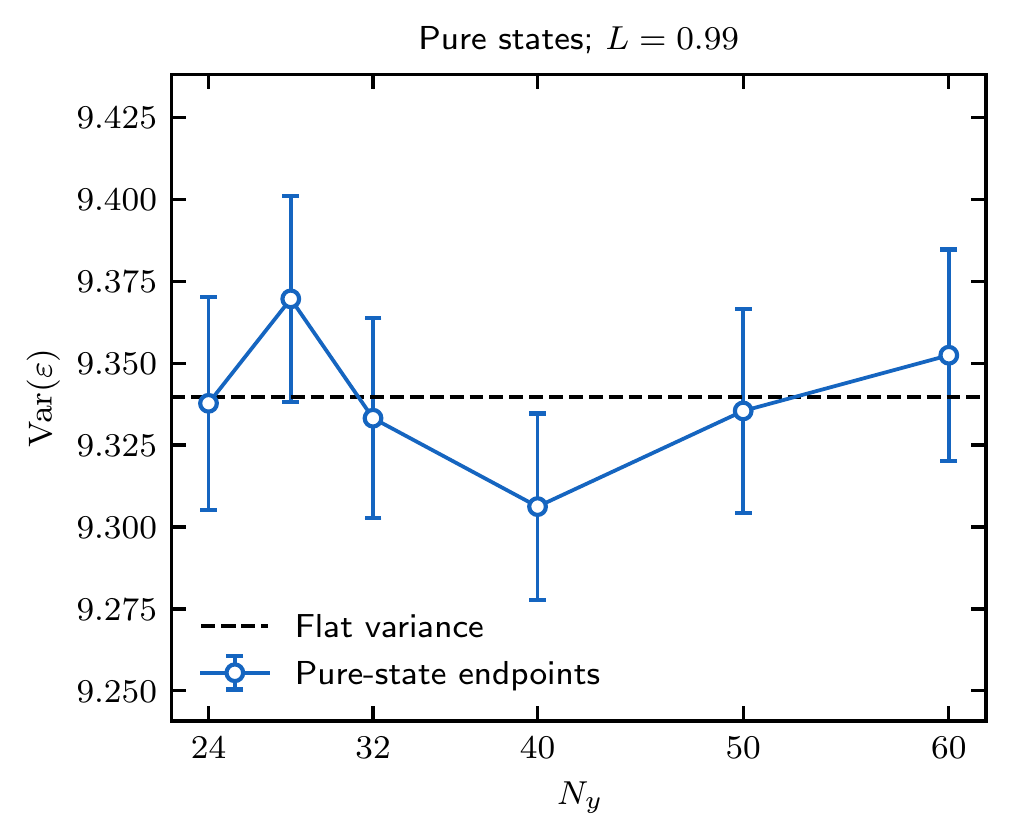

In [6]:
fig,ax=plt.subplots(figsize=(3.375,2.8))
ax.errorbar(summary.Ny,summary.energy_variance,yerr=summary.variance_jackknife_se,
            color='#1565c0',marker='o',mfc='white',ms=4,lw=.9,capsize=2,label='Pure-state endpoints')
ax.axhline(E**2/3,color='black',ls='--',lw=.9,label='Flat variance')
ax.set(xlabel=r'$N_y$',ylabel=r'$\mathrm{Var}(\varepsilon)$',
       title=r'Pure states; $L=0.99$',xticks=[24,32,40,50,60])
ax.legend(loc='lower left')
ax.margins(y=.3)
ax.tick_params(top=True,right=True)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'pure_energy_variance.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'pure_energy_variance.pdf'),str(OUT/'pure_energy_variance')],check=True)
display(Image(filename=str(OUT/'pure_energy_variance.png'),width=600))

## Diagnostics
All six densities integrate to one. Spectral variances use raw retained energies and are independent of the histogram bin count.

In [7]:
diagnostics={**metadata,'bins':BINS,'uniform_window_variance':float(E**2/3),
 'sample_count':600,'sizes':summary.to_dict(orient='records'),
 'checks':{'finite_energies':True,'counts_conserved':True,'unit_area_densities':True,
 'inverse_energy_transform':True,'input_cache_checksums':True}}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(summary[['Ny','retained_modes','energy_variance','variance_jackknife_se']])

,Ny,retained_modes,energy_variance,variance_jackknife_se
0,24,3098,9.337745,0.032569
1,28,3129,9.369625,0.031437
2,32,3120,9.333198,0.030580
3,40,3155,9.306221,0.028425
4,50,3180,9.335416,0.031168
5,60,3196,9.352419,0.032286
